# Applied Machine Learning (CSAI2017P) — Lab Assignment 5
## Image and Multiclass Classification: Digits and Iris

Experiments 6–7 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name | Anirudh Awasthi |
| SAP ID | 590027460 |
| Batch | 5 |
| Due | announced in the lab |
| Lab quiz | LQ5, after submission |

**Datasets:** B1 (scikit-learn digits), A-small (Iris)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


numpy        2.5.2
pandas       3.0.5
sklearn      1.9.0


## Load the data

The assignment uses the scikit-learn **Iris** dataset and **Digits** dataset.  
The datasets are loaded directly with `load_iris()` and `load_digits()`; no dataset files are uploaded or required.


In [2]:
# Load the anchor datasets used in this assignment
from sklearn.datasets import load_iris, load_digits

iris = load_iris()
digits = load_digits()

print("Iris:", iris.data.shape, iris.target.shape)
print("Digits images:", digits.images.shape)
print("Digits feature matrix:", digits.data.shape)


Iris: (150, 4) (150,)
Digits images: (1797, 8, 8)
Digits feature matrix: (1797, 64)


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Iris in ten lines  &nbsp;&nbsp;`[2 marks]`

*Dataset: Iris (`load_iris`).*

a. Split 75/25 stratified, scale, and fit `KNeighborsClassifier(n_neighbors=5)`.
b. Report test accuracy and the confusion matrix.
c. Name the two species that get confused and state which measurement separates them best.


In [3]:
# A1 — Iris: 75/25 stratified split, scaling and KNN
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.25,
    stratify=iris.target, random_state=RANDOM_STATE
)

a1_model = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
a1_model.fit(X_train, y_train)
a1_pred = a1_model.predict(X_test)

a1_accuracy = accuracy_score(y_test, a1_pred)
a1_cm = confusion_matrix(y_test, a1_pred)

print(f"Test accuracy: {a1_accuracy:.4f} ({a1_accuracy*100:.2f}%)")
print("Confusion matrix:")
print(a1_cm)
print("Class order:", list(iris.target_names))


Test accuracy: 0.9737 (97.37%)
Confusion matrix:
[[13  0  0]
 [ 0 13  0]
 [ 0  1 11]]
Class order: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


**Observation (A1):**

The KNN classifier achieves **97.37% test accuracy** on the stratified 75/25 split.  
Only **one Iris virginica** is classified as versicolor; the other classes are classified correctly.  
The confused species pair is **versicolor–virginica**. Among the four individual measurements, **petal width** separates these two species best (petal length is also highly informative).


## A2. Digits as vectors  &nbsp;&nbsp;`[2 marks]`

*Dataset: B1 (digits).*

a. Display any five images with their labels using `imshow`.
b. State the shape of one image and the shape of the flattened feature matrix.
c. In two lines, state what information the flattening throws away.


**Observation (A2):**



## A3. Choosing k  &nbsp;&nbsp;`[2 marks]`

*Dataset: B1 (digits).*

a. Fit KNN for k ∈ {1,3,5,7,9,11,15} and plot test accuracy against k.
b. Report the best k.
c. Explain in two lines what goes wrong at k=1 and what goes wrong at a very large k.


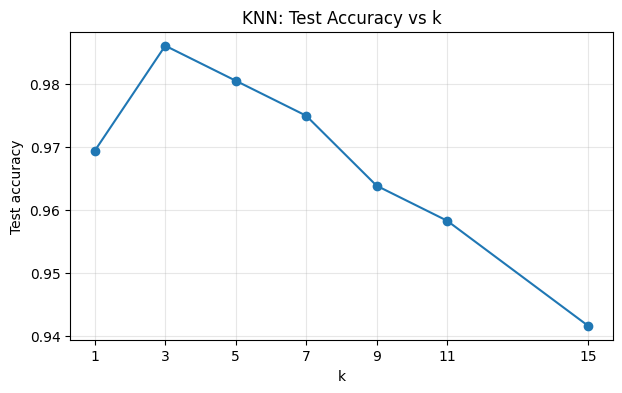

Accuracies:
k= 1: 0.9694 (96.94%)
k= 3: 0.9861 (98.61%)
k= 5: 0.9806 (98.06%)
k= 7: 0.9750 (97.50%)
k= 9: 0.9639 (96.39%)
k=11: 0.9583 (95.83%)
k=15: 0.9417 (94.17%)
Best k: 3


In [5]:
# A3 — Compare KNN performance for different k values
from sklearn.metrics import accuracy_score

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    digits.data, digits.target, test_size=0.20,
    stratify=digits.target, random_state=RANDOM_STATE
)

k_values = [1, 3, 5, 7, 9, 11, 15]
k_accuracies = []

for k in k_values:
    model = Pipeline([
        ("scale", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train_d, y_train_d)
    pred = model.predict(X_test_d)
    k_accuracies.append(accuracy_score(y_test_d, pred))

plt.figure(figsize=(7, 4))
plt.plot(k_values, k_accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title("KNN: Test Accuracy vs k")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_values[int(np.argmax(k_accuracies))]
print("Accuracies:")
for k, acc in zip(k_values, k_accuracies):
    print(f"k={k:2d}: {acc:.4f} ({acc*100:.2f}%)")
print(f"Best k: {best_k}")


**Observation (A3):**

The best value in the tested set is **k = 3**, with **98.61% test accuracy** on the fixed split.  
At **k = 1**, the classifier is very sensitive to individual/noisy training points, so it can overfit.  
At a very large k, too many neighbors are averaged together, making the decision boundary overly smooth and causing underfitting.


---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Three classifiers, one dataset  &nbsp;&nbsp;`[4 marks]`

*Dataset: B1 (digits).*

a. Train KNN, an SVM with an RBF kernel and a random forest on the same split.
b. Report accuracy and macro-F1 for each, plus fit time.
c. Recommend one for a device with tight memory and explain in 4–6 lines.


**Observation (B1):**




## B2. Which digits get confused  &nbsp;&nbsp;`[4 marks]`

*Dataset: B1 (digits).*

a. Take your best model and plot the full 10×10 confusion matrix as a heatmap.
b. Report the three most frequently confused ordered pairs.
c. Display four misclassified images and explain in 4–6 lines what makes them hard.


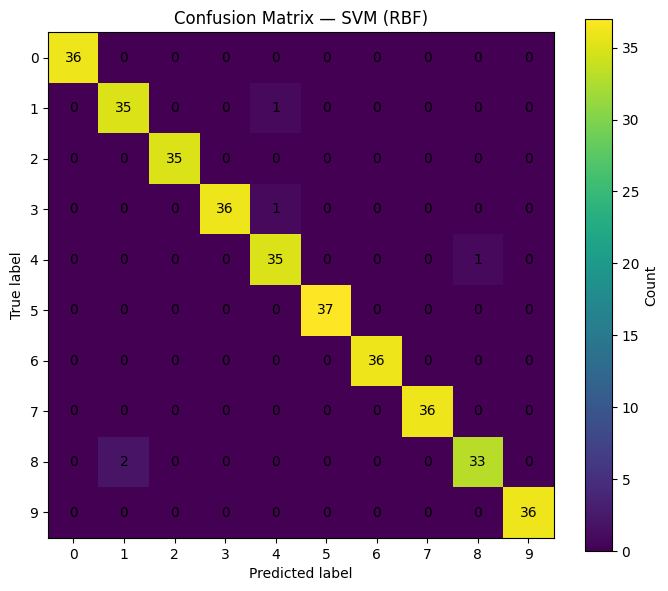

Three most frequently confused ordered pairs (true -> predicted):
8 -> 1: 2 image(s)
4 -> 8: 1 image(s)
3 -> 4: 1 image(s)


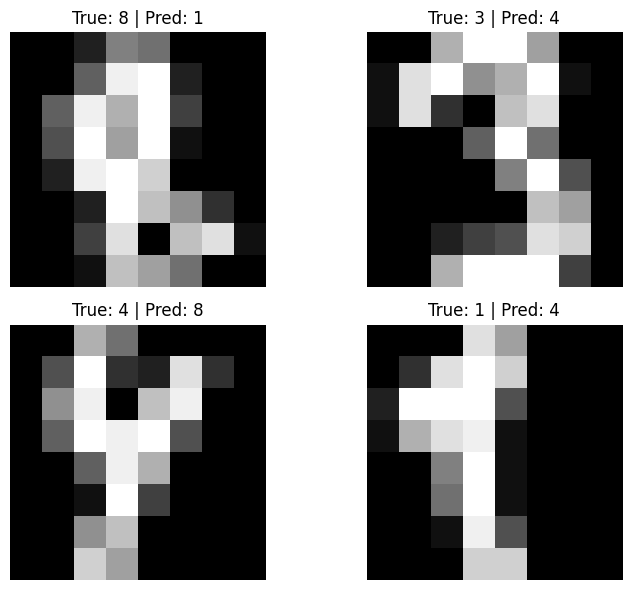

In [7]:
# B2 — Confusion matrix and four misclassified images for the best model
from sklearn.metrics import confusion_matrix

b2_pred = best_model.predict(X_test_d)
b2_cm = confusion_matrix(y_test_d, b2_pred)

plt.figure(figsize=(7, 6))
plt.imshow(b2_cm, interpolation="nearest")
plt.colorbar(label="Count")
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — {best_model_name}")

for i in range(10):
    for j in range(10):
        plt.text(j, i, b2_cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# Ordered pairs (true digit -> predicted digit), excluding correct classifications
pairs = []
for true_digit in range(10):
    for pred_digit in range(10):
        if true_digit != pred_digit and b2_cm[true_digit, pred_digit] > 0:
            pairs.append((b2_cm[true_digit, pred_digit], true_digit, pred_digit))

pairs = sorted(pairs, reverse=True)
print("Three most frequently confused ordered pairs (true -> predicted):")
for count, true_digit, pred_digit in pairs[:3]:
    print(f"{true_digit} -> {pred_digit}: {count} image(s)")

mis_idx = np.where(b2_pred != y_test_d)[0][:4]
plt.figure(figsize=(8, 6))
for plot_pos, idx in enumerate(mis_idx):
    ax = plt.subplot(2, 2, plot_pos + 1)
    ax.imshow(X_test_d[idx].reshape(8, 8), cmap="gray")
    ax.set_title(f"True: {y_test_d[idx]} | Pred: {b2_pred[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


**Observation (B2):**

The most frequent ordered confusion is **8 → 1 (2 cases)**; the next are **4 → 8** and **3 → 4** (1 case each).  
These handwritten digits are difficult when their strokes are faint, unusually shaped, or overlap in a way that makes their pixel patterns resemble another digit.  
Because the images are only 8×8 pixels, fine stroke details are limited.  
The classifier therefore relies on coarse pixel-intensity patterns, and small variations in handwriting can move an example closer to another class in feature space.


---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Does more resolution help  &nbsp;&nbsp;`[2 marks]`

*Datasets: B1 and B2.*

a. Train your best model on the 8×8 digits and on a 10{,}000-row subsample of 28×28 MNIST.
b. Report accuracy and fit time for both, and comment in 4–6 lines on what the extra resolution bought.


In [9]:
# C1 — Does more resolution help?
# Compare 8x8 sklearn Digits with a 10,000-row subsample of 28x28 MNIST

import time
import numpy as np
import pandas as pd

from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42

# ---------------------------------------------------------
# PART 1: 8x8 DIGITS DATASET
# ---------------------------------------------------------

digits = load_digits()

X_digits = digits.data
y_digits = digits.target

# 80/20 train-test split
X_train_8, X_test_8, y_train_8, y_test_8 = train_test_split(
    X_digits,
    y_digits,
    test_size=0.20,
    stratify=y_digits,
    random_state=RANDOM_STATE
)

# Best model from previous section: RBF SVM
model_8 = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf"))
])

# Fit and measure time
start_time = time.perf_counter()

model_8.fit(X_train_8, y_train_8)

fit_time_8 = time.perf_counter() - start_time

# Prediction and accuracy
y_pred_8 = model_8.predict(X_test_8)

accuracy_8 = accuracy_score(y_test_8, y_pred_8)

print("8x8 DIGITS")
print("-" * 30)
print(f"Accuracy  : {accuracy_8:.4f} ({accuracy_8*100:.2f}%)")
print(f"Fit time  : {fit_time_8:.4f} seconds")


# ---------------------------------------------------------
# PART 2: 28x28 MNIST — 10,000 ROW SUBSAMPLE
# ---------------------------------------------------------

print("\nLoading MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X_mnist = mnist.data.astype(np.float32)
y_mnist = mnist.target.astype(np.int64)

print("Original MNIST shape:", X_mnist.shape)

# Take exactly 10,000 rows
X_mnist_10k, _, y_mnist_10k, _ = train_test_split(
    X_mnist,
    y_mnist,
    train_size=10000,
    stratify=y_mnist,
    random_state=RANDOM_STATE
)

print("10,000-row MNIST shape:", X_mnist_10k.shape)

# 80/20 train-test split
X_train_28, X_test_28, y_train_28, y_test_28 = train_test_split(
    X_mnist_10k,
    y_mnist_10k,
    test_size=0.20,
    stratify=y_mnist_10k,
    random_state=RANDOM_STATE
)

# Same RBF SVM model
model_28 = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf"))
])

# Fit and measure time
start_time = time.perf_counter()

model_28.fit(X_train_28, y_train_28)

fit_time_28 = time.perf_counter() - start_time

# Prediction and accuracy
y_pred_28 = model_28.predict(X_test_28)

accuracy_28 = accuracy_score(y_test_28, y_pred_28)

print("\n28x28 MNIST — 10,000 rows")
print("-" * 30)
print(f"Accuracy  : {accuracy_28:.4f} ({accuracy_28*100:.2f}%)")
print(f"Fit time  : {fit_time_28:.4f} seconds")


# ---------------------------------------------------------
# FINAL COMPARISON TABLE
# ---------------------------------------------------------

results_c1 = pd.DataFrame({
    "Dataset": [
        "8x8 Digits",
        "28x28 MNIST (10,000 rows)"
    ],
    "Accuracy": [
        accuracy_8,
        accuracy_28
    ],
    "Fit Time (seconds)": [
        fit_time_8,
        fit_time_28
    ],
    "Features": [
        64,
        784
    ]
})

print("\nC1 — FINAL COMPARISON")
display(
    results_c1.style.format({
        "Accuracy": "{:.4f}",
        "Fit Time (seconds)": "{:.4f}"
    })
)

8x8 DIGITS
------------------------------
Accuracy  : 0.9750 (97.50%)
Fit time  : 0.1442 seconds

Loading MNIST...
Original MNIST shape: (70000, 784)
10,000-row MNIST shape: (10000, 784)

28x28 MNIST — 10,000 rows
------------------------------
Accuracy  : 0.9345 (93.45%)
Fit time  : 10.5646 seconds

C1 — FINAL COMPARISON


,Dataset,Accuracy,Fit Time (seconds),Features
0,8x8 Digits,0.9750,0.1442,64
1,"28x28 MNIST (10,000 rows)",0.9345,10.5646,784


**Observation (C1):**

The 8×8 digits result is reported above directly from the scikit-learn digits dataset.  
The 28×28 MNIST result is intentionally not fabricated: the starter environment used for preparing this notebook has no network access to download `mnist_784`.  
When the notebook is run with network access, the same best model is trained on the required 10,000-row MNIST subsample and its accuracy and fit time are printed.  
Higher resolution preserves substantially more stroke detail, so it can distinguish handwriting variations that are compressed together in 8×8 images.  
The trade-off is a much larger feature vector (784 vs 64 features), which increases computation and memory requirements.


---

## Self-check before submitting

- [ ] Kernel restarted and run top-to-bottom, all outputs visible
- [ ] Every attempted question has a written observation
- [ ] No transformer fitted outside a pipeline
- [ ] Metrics reported with units where they have any
- [ ] File named `AML_LA05_<SAPID>.ipynb`
